## Figure 4D
Due to Trodes tracking error, using LED for head direction is not adviced! Use Eric's gyroscope integrater instead!

In [1]:
### For each remote arm representation, calculate the cos(animal_head, arm)

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [31]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, Imu

In [5]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

# test start

In [6]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [7]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

In [11]:
#Imu()

In [13]:
output_folder = '/stelmo/shijie/gyro/'
nwb_file_name = "julio20230808.nwb"
session_name = "08_Seq2Session4"
trial = 27

nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
key_imu={'nwb_file_name':nwb_copy_file_name,
                  'epoch':int(session_name[:2]),
                  'trial':trial,
                  "parameter":"big_acc_bias"}
pos_info_ssm = Imu().fetch1_dataframe(key_imu)

In [14]:

position_name = session2position_name(nwb_copy_file_name, session_name)
pos_info_2d_session = (IntervalPositionInfo() & {
    'nwb_file_name':nwb_copy_file_name,
    'interval_list_name':position_name,
    'position_info_param_name':'default_decoding'}).fetch1_dataframe()

[2026-04-12 17:15:48,326][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2026-04-12 17:15:48,340][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2026-04-12 17:15:48,352][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb
[2026-04-12 17:15:48,362][WARNING]: Skipped checksum for file with hash: a2539cc4-efe6-d9d3-8203-fbe3ea6465c5, and path: /stelmo/nwb/analysis/julio20230808/julio20230808_MASPBFOJ0W.nwb


In [15]:
(t0,t1) = (pos_info_ssm.index[0], pos_info_ssm.index[-1]) 
pos_info_2d = select_subset_helper_pd(pos_info_2d_session,(t0,t1))
pos_info_2d_subset = interpolate_to_new_time(pos_info_2d, pos_info_ssm.index)

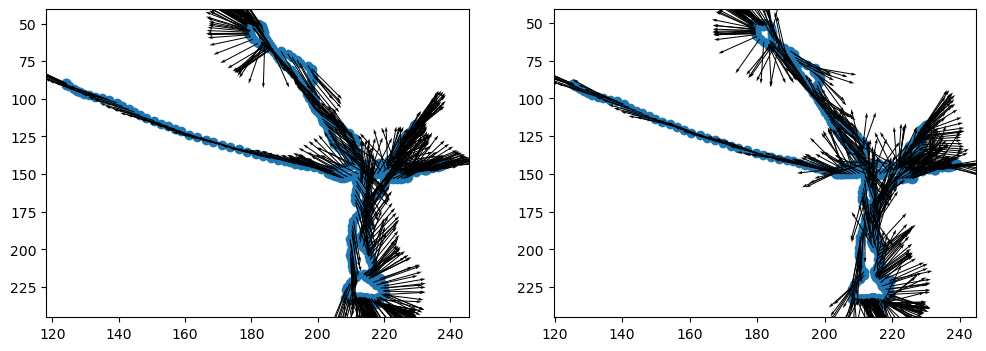

In [21]:
quiver_scale = 10
fig, axes = plt.subplots(1,2,figsize = (12,4))
axes[0].scatter(pos_info_ssm.head_position_x, pos_info_ssm.head_position_y)
axes[0].quiver(pos_info_ssm.head_position_x, pos_info_ssm.head_position_y, 
               np.cos(pos_info_ssm.head_orientation), np.sin(pos_info_ssm.head_orientation), angles='xy',
               scale = quiver_scale)
axes[1].scatter(pos_info_2d_subset.head_position_x, pos_info_2d_subset.head_position_y)
axes[1].quiver(pos_info_2d_subset.head_position_x, pos_info_2d_subset.head_position_y, 
               np.cos(pos_info_2d_subset.head_orientation), np.sin(pos_info_2d_subset.head_orientation), angles='xy', 
               scale = quiver_scale)

axes[0].yaxis.set_inverted(True)
axes[1].yaxis.set_inverted(True)

In [22]:
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal

In [23]:
loaded_data = load_remote_animal(
        "julio", ["20230808"],
        "params_both_max_run_time_2_state",
        'default_decoding_gpu_4armMaze',
        spyglass = True,
        proportion = 0.1, use_1d = True)
    
(info_animal,
        time_intervals_animal, arm_identities_animal
            ) = (loaded_data['info_animal'],
                loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Loading from spyglass database instead of pickle file.
julio20230808_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230808_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}


In [46]:
(angles, v1, v2,
 max_posterior_2d, head_orientation,
 animal_location, parsed_info, parsed_arm
) = find_angle_animal("julio", ["20230808"], ["20230808"],
                      "params_both_max_run_time_2_state", '2Dheadspeed_above_4',
                      'default_decoding_gpu_4armMaze', 0.1, use_1d = 1, debug = False,
                      use_gyro = True, imu_param_name = "big_acc_bias")

Loading from spyglass database instead of pickle file.
julio20230808_.nwb
No triggered decode found for  {'nwb_file_name': 'julio20230808_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
some missing position data


In [52]:
v2

array([[ 0.95716055, -0.28955774],
       [ 0.95709088, -0.28978792],
       [ 0.95702118, -0.29001802],
       [ 0.95906907, -0.28317226],
       [ 0.95899755, -0.28341436],
       [ 0.95892599, -0.28365639],
       [ 0.95885439, -0.28389833],
       [ 0.95878274, -0.2841402 ],
       [ 0.95871106, -0.28438198],
       [ 0.95756824, -0.28820664],
       [ 0.95749735, -0.28844206],
       [ 0.95742643, -0.28867739],
       [ 0.95735546, -0.28891265],
       [ 0.95625199, -0.29254423],
       [ 0.95828005, -0.28583098],
       [ 0.95931039, -0.28235364]])

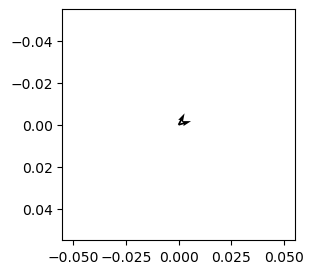

In [63]:
fig, axe = plt.subplots(1,1,figsize = (3,3))
axe.quiver([0,0],[0,0],[0.46, 0.96], [0.88, 0.28])#angles='xy')
#axe.quiver(0,0,931039, -0.28235364,angles='xy')
axe.yaxis.set_inverted(True)

In [64]:
np.arccos(0.46*0.88 + 0.96*0.28)

0.8317274692338602

In [50]:
angles

[1.7547182590053414,
 1.8241866173723014,
 0.9773868980311335,
 0.949298545759185,
 1.0138778876472714,
 0.8022707548103358]

In [47]:
parsed_info

[17:48:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[17:48:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


[['julio20230808_.nwb', '02_Seq2Session1', 41],
 ['julio20230808_.nwb', '02_Seq2Session1', 41],
 ['julio20230808_.nwb', '08_Seq2Session4', 27],
 ['julio20230808_.nwb', '08_Seq2Session4', 27],
 ['julio20230808_.nwb', '08_Seq2Session4', 27],
 ['julio20230808_.nwb', '08_Seq2Session4', 27]]

In [48]:
parsed_arm

[2, 2, 4, 4, 4, 4]

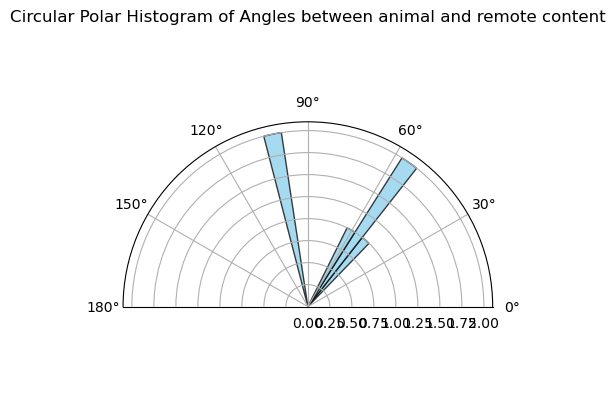

In [49]:
# Create a figure and a polar subplot
fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

# Plot the histogram
# 'bins' controls the number of sectors
# 'alpha' controls the transparency
n, bins, patches = ax.hist(angles, bins=10, alpha=0.75, color='skyblue', edgecolor='black')

# Set the title
ax.set_title('Circular Polar Histogram of Angles between animal and remote content')
ax.set_thetamin(0)
ax.set_thetamax(180)

plt.show()
# Display the plot

In [26]:
ind = 
print(parsed_info[ind])
print(parsed_arm[ind])

In [ ]:
ind = 2

In [30]:
arm_identities_animal

[[4, 2, 2], [0, 4, 0, 3, 3], [2, 4, 4, 4, 4, 4]]

In [29]:
np.concatenate(time_intervals_animal)[5][0]

1691517696.2174284

In [ ]:
### load video add

In [91]:
from spyglass.shijiegu.video import load_video_and_timestamps, make_mp4
from trodestrack.data.visualize_filter_overlay_fast import create_filter_overlay_video_fast
from spyglass.shijiegu.video import increase_brightness
import cv2

[14:47:37][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [92]:
cap, timestamps, meters_per_pixel = load_video_and_timestamps(nwb_copy_file_name, session_name)

In [93]:
frameToPlot = np.argwhere(np.logical_and(timestamps>=t0,timestamps<=t1)).ravel()
frame0 = frameToPlot[0]
frameLast = frameToPlot[-1]

fps = cap.get(cv2.CAP_PROP_FPS) # Gets the frames per second
frameSize = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

frames = []
for fi in range(len(timestamps)):##len(frameToPlot)):
    t = timestamps[fi]

    ret, frame = cap.read()
    frameBrighter = increase_brightness(frame)
    if fi >= frame0 and fi <= frameLast:
        frames.append(frame)
    if fi > frameLast:
        break

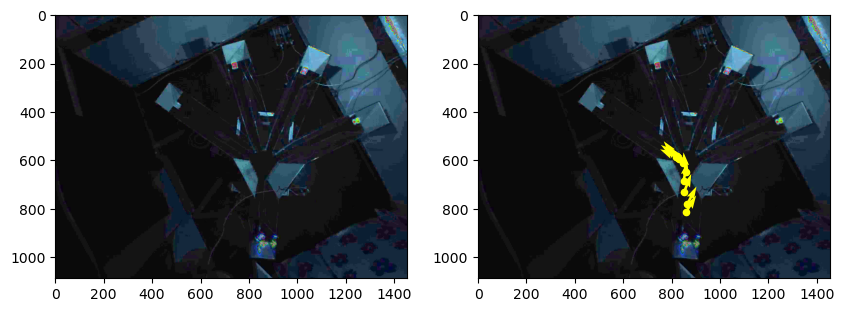

In [94]:
pixel_per_cm = 0.25
arrow_length = 100

fig, axes = plt.subplots(1,2,figsize = (10,8))

ind = 10
axes[0].imshow(frames[ind]*10)

axes[1].imshow(frames[ind]*10)

for ind in range(1300,1350,5):
    (x, y) = (np.array(pos_info_ssm.head_position_x)[ind], np.array(pos_info_ssm.head_position_y)[ind])
    axes[1].scatter(x/pixel_per_cm,
                    y/pixel_per_cm, color = 'yellow', s = 20)
    
    arrow_heading = np.array(pos_info_ssm.head_orientation) + np.pi
    dx = arrow_length * np.cos(arrow_heading)[ind]
    dy = arrow_length * np.sin(arrow_heading)[ind]
    axes[1].quiver(x/pixel_per_cm,y/pixel_per_cm, dx, dy, linewidth = 5, color = 'yellow', angles = 'xy')


In [67]:
#outputName = f'/cumulus/shijie/gyro/position_{nwb_file_name}_{session_name}_trial{trialID}'
outputName = f'position_{nwb_file_name}_{session_name}_trial{trial}'
make_mp4(cap, timestamps, t0, t1, outputName)

OpenCV: FFMPEG: tag 0x5634504d/'MP4V' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


'position_julio20230731.nwb_04_Seq2Session2_trial12_rawposition.mp4'

In [24]:
# data
file_path = os.path.join(output_folder,f'tracking_{nwb_file_name}_{session_name}_trial{trial}_result.pkl')#with open(imu_path, 'rb') as file:
with open(file_path, 'rb') as file:
    packed_data = pickle.load(file)
input_data = packed_data["packed_data"]

file_path = os.path.join(output_folder,f'tracking_{nwb_file_name}_{session_name}_trial{trial}_result.pkl')
with open(file_path, 'rb') as file:
    result = pickle.load(file)
       
result = result["result"] 

spatial_subset_df = load_tracking_data_position(output_folder, nwb_file_name, session_name, trial)

In [26]:
input_data.meters_per_pixel

0.0025

In [80]:
spatial_subset_df

,video_frame_ind,non_repeat_timestamp_labels,xloc2,yloc2,xloc,yloc
time,,,,,,
1.690829e+09,0.0,1.0,850.0,944.0,847.0,912.0
1.690829e+09,1.0,1.0,851.0,943.0,847.0,914.0
1.690829e+09,2.0,1.0,852.0,943.0,849.0,915.0
1.690829e+09,3.0,1.0,854.0,943.0,849.0,916.0
1.690829e+09,4.0,1.0,853.0,944.0,847.0,917.0
...,...,...,...,...,...,...
1.690829e+09,1396.0,1.0,495.0,354.0,512.0,371.0
1.690829e+09,1397.0,1.0,495.0,352.0,513.0,371.0
1.690829e+09,1398.0,1.0,495.0,350.0,513.0,370.0


In [81]:
create_filter_overlay_video_fast(
    video_path = outputName + '_rawposition.mp4',
    data = input_data,
    filter_result = result,
    t_filter = input_data.t_cam,
    position_df = spatial_subset_df,
    output_path = f"filter_{nwb_file_name}_{session_name}.mp4",
    start_time=0.0,
    duration=t1-t0,
    fps=25.0
)

FAST FILTER OVERLAY VIDEO

Input: position_julio20230731.nwb_04_Seq2Session2_trial12_rawposition.mp4
  Resolution: 1456×1088
  Frame rate: 23.0 fps

Output: filter_julio20230731.nwb_04_Seq2Session2.mp4
  Start: 0.0s, Duration: 59.8s
  Output fps: 25.0

Generating 1494 frames...
  Progress: 0/1494 frames (0.0%)
  Progress: 30/1494 frames (2.0%)
  Progress: 60/1494 frames (4.0%)
  Progress: 90/1494 frames (6.0%)
  Progress: 120/1494 frames (8.0%)
  Progress: 150/1494 frames (10.0%)
  Progress: 180/1494 frames (12.0%)
  Progress: 210/1494 frames (14.1%)
  Progress: 240/1494 frames (16.1%)
  Progress: 270/1494 frames (18.1%)
  Progress: 300/1494 frames (20.1%)
  Progress: 330/1494 frames (22.1%)
  Progress: 360/1494 frames (24.1%)
  Progress: 390/1494 frames (26.1%)
  Progress: 420/1494 frames (28.1%)
  Progress: 450/1494 frames (30.1%)
  Progress: 480/1494 frames (32.1%)
  Progress: 510/1494 frames (34.1%)
  Progress: 540/1494 frames (36.1%)
  Progress: 570/1494 frames (38.2%)
  Progress:

# test end

In [90]:
list_of_days_animals = {}
encoding_set_animals = {}
classifier_param_name_animals = {}
success_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'


animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [294]:
proportion = 0.1
use_1d = 1

In [341]:

angles = find_angle_animal(animal, list_of_days_animals[animal],
                           encoding_set_animals[animal],
                           classifier_param_name_animals[animal],
                           proportion, use_1d)

[2025-10-21 21:26:20,064][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2025-10-21 21:26:20,084][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb
[2025-10-21 21:26:20,090][WARNING]: Skipped checksum for file with hash: a2f4d444-d610-b6bc-5bb5-f6658a34835c, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_VGTK6H1V1J.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_use1d1.pkl':


[21:26:26][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-21 21:26:26,744][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:26,769][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:26,778][WARNING]: Skipped checksum for file with hash: b46db89b-63e8-05f4-9514-9a0296148a58, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_PN8Z1436QL.nwb
[2025-10-21 21:26:32,205][WARNING]: Skipped checksum for file with hash: 8b496b29-6ced-5902-d459-8fe3

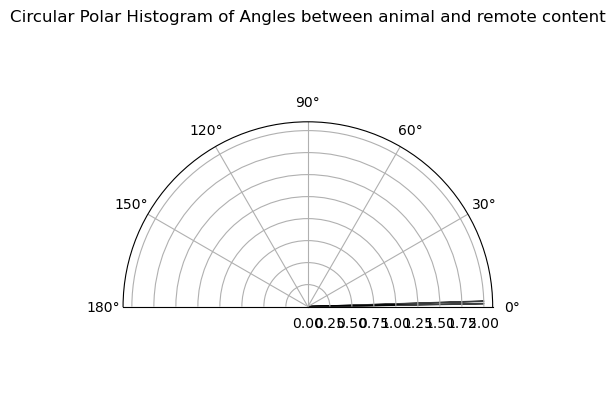

In [40]:
# Create a figure and a polar subplot
fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

# Plot the histogram
# 'bins' controls the number of sectors
# 'alpha' controls the transparency
n, bins, patches = ax.hist(np.deg2rad(angles), bins=10, alpha=0.75, color='skyblue', edgecolor='black')

# Set the title
ax.set_title('Circular Polar Histogram of Angles between animal and remote content')
ax.set_thetamin(0)
ax.set_thetamax(180)

plt.show()
# Display the plot

### Playground

In [76]:
from spyglass.shijiegu.load import load_decode
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.common.common_position import TrackGraph, IntervalLinearizedPosition, IntervalPositionInfo

In [298]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [319]:
info_animal[39]

['lewis20240109_.nwb', '06_Rev2Session3', [28, 28, 28]]

[15:15:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[15:15:16][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [323]:
#arm_identities_animal

In [337]:
ind = 39

In [338]:
print(info_animal[ind], arm_identities_animal[ind])

['lewis20240109_.nwb', '06_Rev2Session3', [28, 28, 28]] [2, 2, 2]


In [327]:
nwb_copy_file_name, session_name, trialID = info_animal[ind]


# 1.
decode = load_decode(nwb_copy_file_name,session_name,'default_decoding_gpu_4armMaze','2Dheadspeed_above_4')
position_axis = np.array(decode.coords['position'])

In [328]:
q = {"nwb_file_name": nwb_copy_file_name,
        "epoch":int(session_name[:2]),
        "proportion":str(proportion)}
    
log_df = ChangeofMind().fetch1_dataframe(q)

[2025-10-21 21:17:04,632][WARNING]: Skipped checksum for file with hash: d5025152-afbe-f71b-4362-e069ee70da9c, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_TQBNEQPF6M.nwb


In [339]:
t0, t1 = time_intervals_animal[ind][0]

timestamp_H         1704837183.325913
Home                              1.0
timestamp_O         1704837204.335067
OuterWellIndex                    4.0
rewardNum                         2.0
change_of_mind                   True
CoMMaxProportion             0.828244
initial_choice                    1.0
initial_time        1704837192.212236
proportion_arm1              0.306349
proportion_arm2              0.828244
proportion_arm3                   0.0
proportion_arm4                   0.0
CoMNum_by_time                      3
CoMNum_by_arm                       2
current                           4.0
future_H                          4.0
future_O                          1.0
past                              3.0
past_reward                       2.0
Name: 14, dtype: object

In [330]:
# 2. get decode and animal head direction
position_name = session2position_name(nwb_copy_file_name, session_name)
position_info = (IntervalPositionInfo() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe()
position_info1d = (IntervalLinearizedPosition() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe() #for debug use only

pos2d_subset = select_subset_helper_pd(position_info,(t0,t1))
pos1d_subset = select_subset_helper_pd(position_info1d,(t0,t1))#for debug use only

decode_subset = select_subset_helper(decode,(t0,t1),target_len = len(pos2d_subset),
                                         epsilon = 0.001)
posterior_position_subset = decode_subset.acausal_posterior.sum(dim='state')
if np.abs(len(decode_subset.time) - len(pos2d_subset)) <= 3:
    print("small mismatch")
    minlen = np.min([len(decode_subset.time),len(pos2d_subset)])
    posterior_position_subset = posterior_position_subset[:minlen]
    pos2d_subset = pos2d_subset.iloc[:minlen]
    
max_posterior_1d = np.array(position_axis[posterior_position_subset.argmax(dim = 'position')])

# 3.
max_posterior_2d = np.array([loc1d_to_2d(loc1d, linear_map, nodes) for loc1d in max_posterior_1d])

[2025-10-21 21:17:14,441][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[2025-10-21 21:17:14,463][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[2025-10-21 21:17:14,469][WARNING]: Skipped checksum for file with hash: 2bab50d4-5b0d-4135-f8be-48329ef92679, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_2G65EC51OX.nwb
[21:17:14][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-21 21:17:14,583][WARNING]: Skipped checksum for file with hash: a3229264-c4c5-f19f-83c2-4ea2

small mismatch


In [331]:
# 4. Get animal head direction
head_orientation = np.array(pos2d_subset.head_orientation)
head_orientation_unit = np.hstack((np.cos(head_orientation).reshape((-1,1)),np.sin(head_orientation).reshape((-1,1)))) #unit vector

# Get max_posterior_2d - animal location
animal_location = np.hstack((np.array(pos2d_subset.head_position_x).reshape(-1,1),np.array(pos2d_subset.head_position_y).reshape(-1,1)))
displacement_unit = max_posterior_2d - animal_location
displacement_unit = displacement_unit / np.linalg.norm(displacement_unit, axis = 1).reshape((-1,1))

# finally: return degree
dot_product = [np.dot(head_orientation_unit[i],displacement_unit[i].T) for i in range(displacement_unit.shape[0])]
angle = np.degrees(np.arccos(np.clip(dot_product, -1.0, 1.0)))



In [332]:
angle

array([14.44713613, 14.48218834, 14.51722652, 14.55225064, 14.5872607 ,
       14.62225669, 14.65723861, 14.69220645, 14.72716019, 14.76209984,
       14.79702538, 14.83193681, 14.86683412, 14.90171729, 14.93658634,
       14.97144174, 15.00648324, 15.07571997, 15.11071878, 15.14550336,
       15.18027325, 15.21502896, 15.24977046, 15.28449776, 15.31921085,
       15.35390973, 15.38859437, 14.52662663, 12.62564912, 11.61687587])

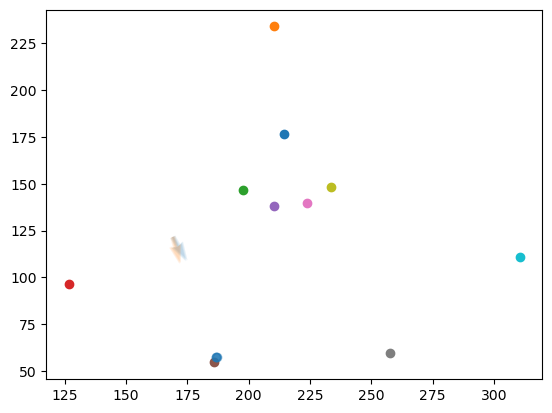

In [334]:
fig, ax = plt.subplots()

for key in nodes:
     node = nodes[key]
     for n in node:
         ax.scatter(n[0],n[1])
ax.scatter(max_posterior_2d[::10,0] + np.random.rand(len(max_posterior_2d[::10,0]))*.1,
            max_posterior_2d[::10,1] + + np.random.rand(len(max_posterior_2d[::10,0]))*.1, alpha = 0.5)

ax.quiver(animal_location[::10,0],animal_location[::10,1],
           head_orientation_unit[::10,0],head_orientation_unit[::10,1],color = 'C0',alpha = 0.1)
ax.quiver(animal_location[::10,0],animal_location[::10,1],
           displacement_unit[::10,0],displacement_unit[::10,1],color = 'C1',alpha = 0.1)


# Invert the y-axis (make it upside down)
#ax.invert_yaxis()

array([225.12560103, 136.2734064 ])

In [ ]:
#plt.plot(max_posterior_1d)
for key in nodes:
    node = nodes[key]
    for n in node:
        plt.scatter(n[0],n[1])
plt.scatter(max_posterior_2d[:,0], max_posterior_2d[:,1])